# Comparative Analysis and Greeks

This notebook overlays the calibrated Heston smile on the market smile and compares Black-Scholes and Heston sensitivities. Pricing formulas, implied-vol conversion, finite-difference Greeks, and plotting helpers live in `src`.

In [1]:
from pathlib import Path
import sys

import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
from IPython.display import display

PROJECT_ROOT = Path.cwd()
if PROJECT_ROOT.name == "notebook":
    PROJECT_ROOT = PROJECT_ROOT.parent

if str(PROJECT_ROOT) not in sys.path:
    sys.path.insert(0, str(PROJECT_ROOT))

from src.heston.calibration import evaluate_heston_fit, prepare_calibration_data, summarize_calibration_errors
from src.heston.pricing import default_phi_grid
from src.heston.smile import greeks_comparison_on_grid, heston_smile_surface, select_expiries_by_target_tenors
from src.market_data import ENRICHED_OPTIONS_PATH
from src.types import HestonParams
from src.utils import prepare_iv_dataset
from src.visualization import plot_greek_comparison, plot_heston_smile_overlay

pd.set_option("display.float_format", lambda x: f"{x:.6f}")
plt.style.use("seaborn-v0_8-whitegrid")


## Data Used for Final Comparison

`iv_all` is the all-valid-options volatility smile from the Black-Scholes notebook. `calib` is the filtered OTM dataset used for Heston calibration diagnostics and parameter estimation.


In [2]:
if not ENRICHED_OPTIONS_PATH.exists():
    raise FileNotFoundError("Run notebook/01_data_acquisition.ipynb before this notebook.")

options = pd.read_csv(ENRICHED_OPTIONS_PATH)

iv_all = prepare_iv_dataset(
    options,
    min_mid=0.10,
    moneyness_bounds=(0.85, 1.15),
    iv_bounds=(0.03, 0.80),
    use_otm_only=False,
)

calib = prepare_calibration_data(
    options,
    selection="otm",
    moneyness_range=(0.85, 1.15),
    min_price=0.50,
    min_open_interest=10,
    min_volume=0,
    max_relative_spread=0.15,
    t_bounds=(14 / 365, 1.0),
    iv_bounds=(0.05, 1.00),
    delta_abs_bounds=(0.05, 0.40),
    require_positive_bid=True,
    weight_scheme="expiry_option_type",
)

comparison_summary = pd.DataFrame(
    [
        {"dataset": "all valid IV", "rows": len(iv_all), "expiries": iv_all["expiry"].nunique()},
        {"dataset": "calibration", "rows": len(calib), "expiries": calib["expiry"].nunique()},
    ]
)
display(comparison_summary)

display(
    iv_all.groupby("expiry", observed=False)
    .agg(
        all_valid_count=("strike", "size"),
        calls=("option_type", lambda x: (x == "call").sum()),
        puts=("option_type", lambda x: (x == "put").sum()),
        T=("T", "first"),
        mean_iv=("iv", "mean"),
    )
    .reset_index()
)

,dataset,rows,expiries
0,all valid IV,3568,24
1,calibration,1061,16


,expiry,all_valid_count,calls,puts,T,mean_iv
0,2026-05-08,134,61,73,0.019178,0.161679
1,2026-05-15,257,118,139,0.038356,0.205130
2,2026-05-22,260,129,131,0.057534,0.205559
3,2026-05-29,280,141,139,0.076712,0.204903
4,2026-06-05,213,100,113,0.095890,0.190553
5,2026-06-18,79,40,39,0.131507,0.187946
6,2026-06-30,266,136,130,0.164384,0.197374
7,2026-07-17,77,43,34,0.210959,0.178510
8,2026-07-31,267,150,117,0.249315,0.194937
9,2026-08-21,76,43,33,0.306849,0.182405


## Calibrated Heston Parameters

In [3]:
calibrated_params = HestonParams(
    v0=0.022880285074712292,
    kappa=2.516843420724343,
    theta=0.06582187265330411,
    sigma_v=1.0672219579865891,
    rho=-0.7120463331140945,
)
phi_grid = default_phi_grid(max_phi=200.0, n_points=2000)
variance_half_life_years = np.log(2.0) / calibrated_params.kappa

parameter_table = pd.DataFrame(
    [
        {"parameter": "v0", "value": calibrated_params.v0, "interpretation": f"initial vol = {calibrated_params.vol_0:.2%}"},
        {"parameter": "kappa", "value": calibrated_params.kappa, "interpretation": "variance mean reversion speed"},
        {"parameter": "theta", "value": calibrated_params.theta, "interpretation": f"long-run vol = {calibrated_params.vol_long:.2%}"},
        {"parameter": "sigma_v", "value": calibrated_params.sigma_v, "interpretation": "volatility of variance"},
        {"parameter": "rho", "value": calibrated_params.rho, "interpretation": "spot-vol correlation"},
        {"parameter": "Feller ratio", "value": calibrated_params.feller_ratio, "interpretation": "2*kappa*theta/sigma_v^2"},
        {"parameter": "variance half-life", "value": variance_half_life_years, "interpretation": f"{variance_half_life_years * 12:.1f} months"},
    ]
)
display(parameter_table)

fit = evaluate_heston_fit(calib, calibrated_params, phi_grid=phi_grid, include_model_iv=True)
display(summarize_calibration_errors(fit))


,parameter,value,interpretation
0,v0,0.022880,initial vol = 15.13%
1,kappa,2.516843,variance mean reversion speed
2,theta,0.065822,long-run vol = 25.66%
3,sigma_v,1.067222,volatility of variance
4,rho,-0.712046,spot-vol correlation
5,Feller ratio,0.290902,2*kappa*theta/sigma_v^2
6,variance half-life,0.275403,3.3 months


,metric,value,description
0,price_RMSE,0.307413,"RMSE of Heston price minus market mid price, i..."
1,relative_price_RMSE,0.050960,RMSE of relative price errors.
2,IV_proxy_RMSE,0.003404,RMSE of price error divided by Black-Scholes v...
3,price_bias,-0.007647,Mean Heston price minus market mid price.
4,IV_RMSE,0.012858,RMSE of model implied volatility minus market ...
5,IV_bias,0.005673,Mean model implied volatility minus market imp...
6,model_IV_success_rate,1.000000,Share of rows where model implied volatility w...


## Calibrated Heston Smile

In [4]:
heston_smiles = heston_smile_surface(
    market_data=iv_all,
    params=calibrated_params,
    expiries=sorted(iv_all["expiry"].unique()),
    moneyness_range=(0.85, 1.15),
    n_strikes=51,
    phi_grid=phi_grid,
)

heston_smile_summary = pd.DataFrame(
    [
        {"metric": "rows", "value": len(heston_smiles)},
        {"metric": "expiries", "value": heston_smiles["expiry"].nunique()},
        {"metric": "model_iv_success_rate", "value": heston_smiles["heston_iv"].notna().mean()},
        {"metric": "min_heston_iv", "value": heston_smiles["heston_iv"].min()},
        {"metric": "max_heston_iv", "value": heston_smiles["heston_iv"].max()},
    ]
)
display(heston_smile_summary)


,metric,value
0,rows,1224.000000
1,expiries,24.000000
2,model_iv_success_rate,0.977124
3,min_heston_iv,0.099511
4,max_heston_iv,0.414217


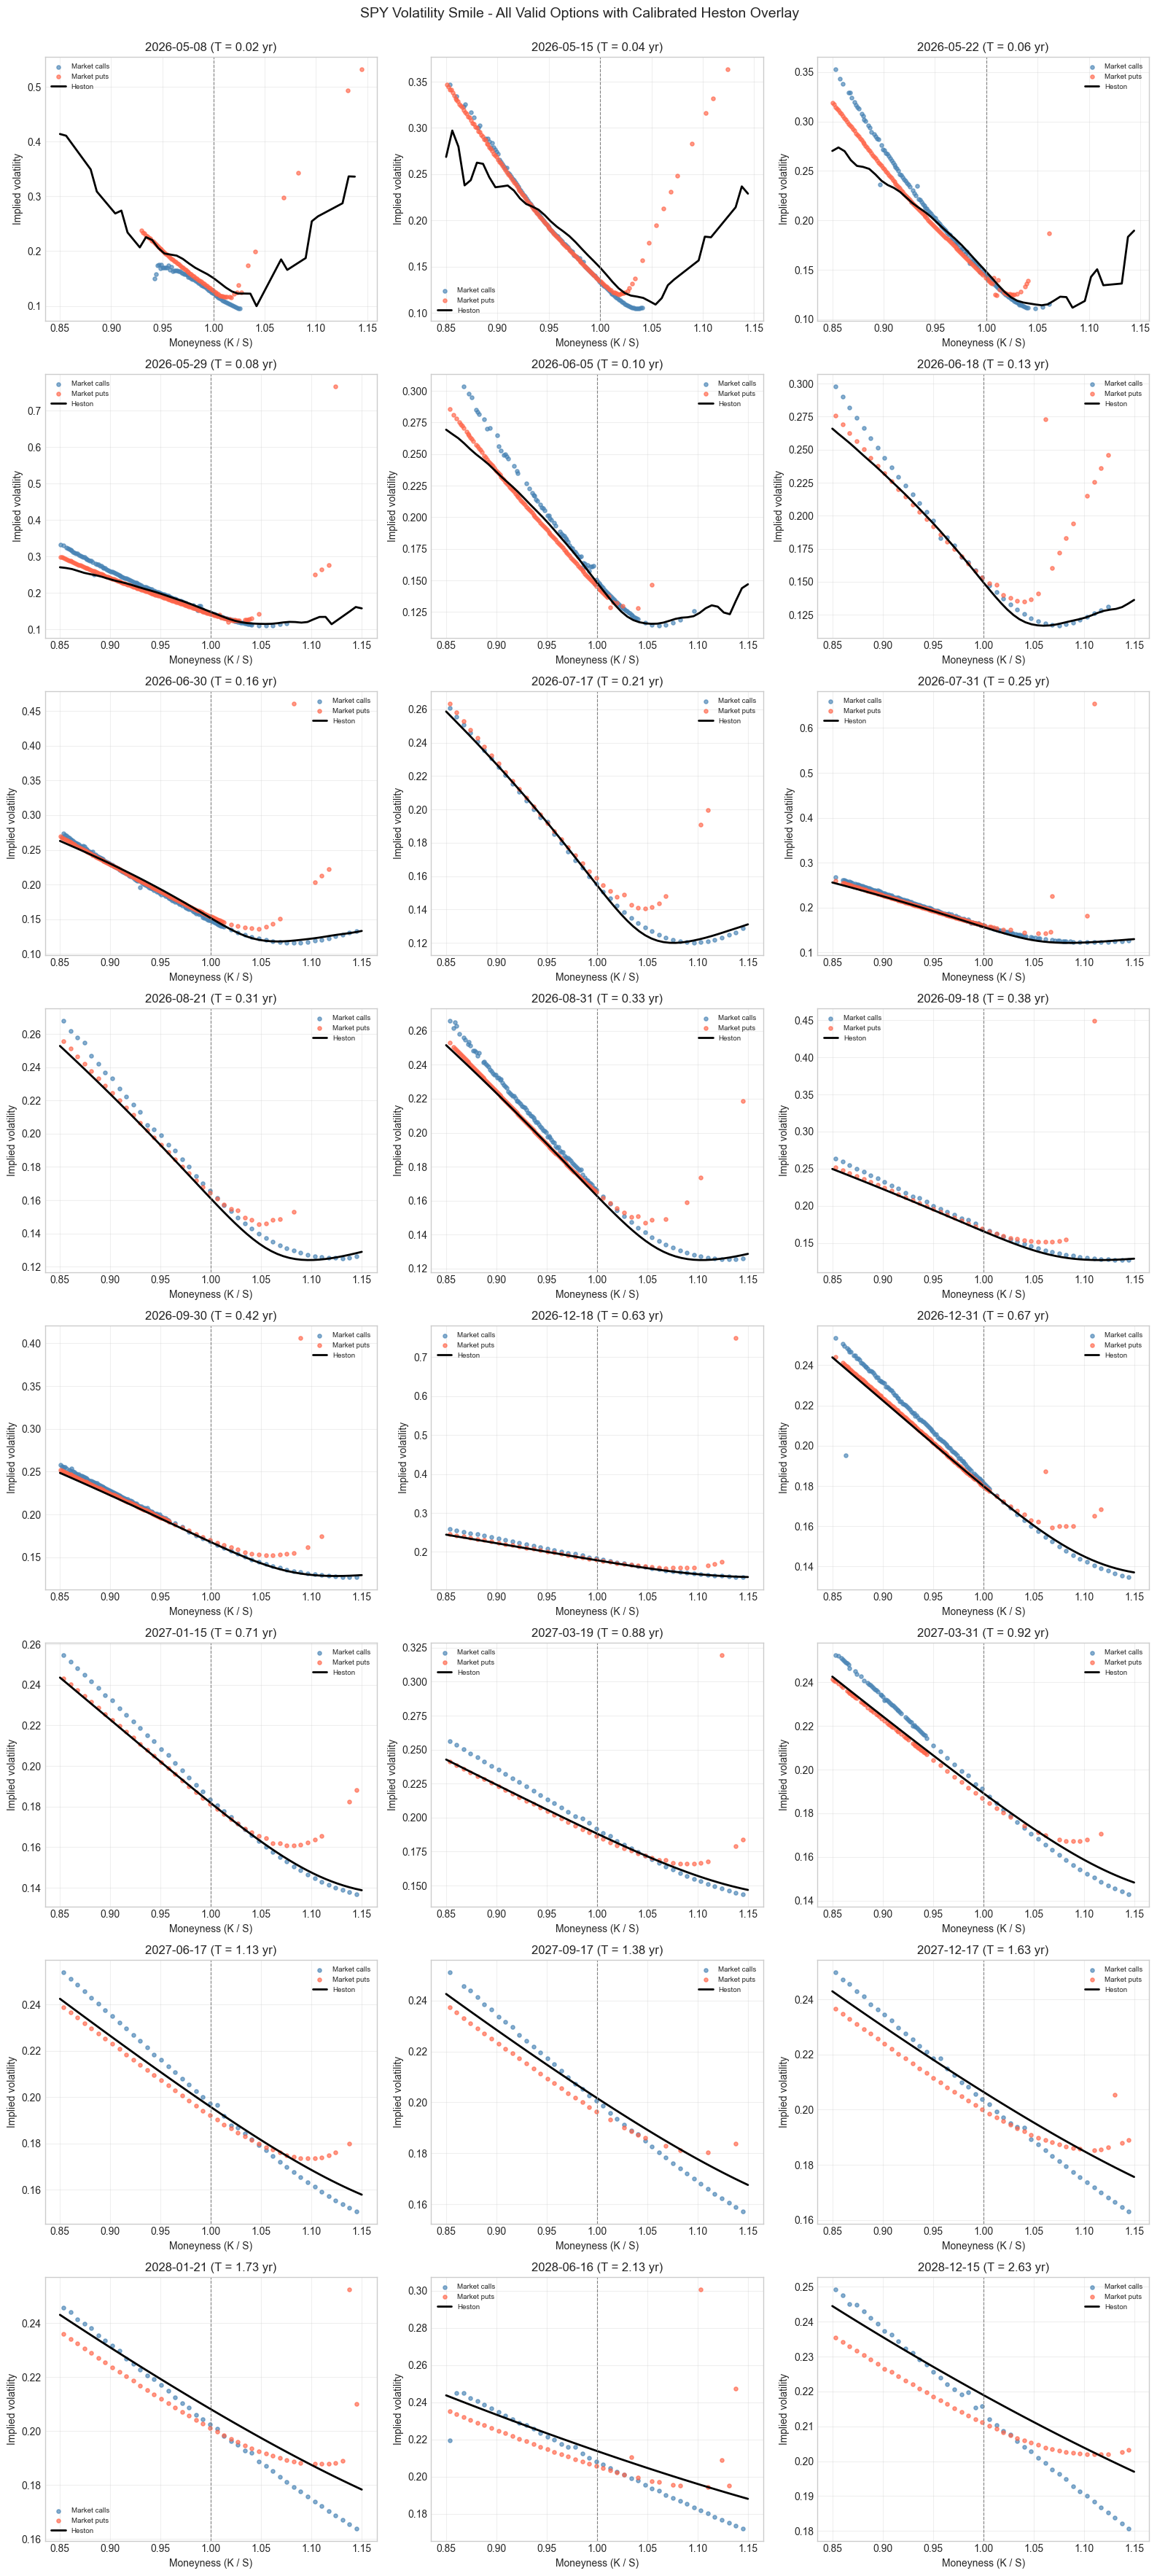

In [5]:
fig, axes = plot_heston_smile_overlay(
    market_df=iv_all,
    heston_df=heston_smiles,
    market_iv_col="iv",
    x_col="moneyness",
    title="SPY Volatility Smile - All Valid Options with Calibrated Heston Overlay",
    columns=3,
)
plt.show()

The colored points are the all-valid-options market smile from the Black-Scholes analysis. The black line is the Heston-implied volatility curve generated from the latest calibrated parameters. Expiries beyond the calibration window are shown as model extrapolation.


## Delta and Vega Comparison

Black-Scholes uses an interpolated market OTM implied-volatility curve at each selected maturity. Heston uses the single calibrated stochastic-volatility process. Both models are evaluated on the same synthetic moneyness grid, so equal point counts are intentional. The selected maturities stay inside the Heston calibration window.


In [6]:
greek_expiries = select_expiries_by_target_tenors(
    calib,
    target_tenors=(0.10, 0.50, 0.90),
    include_longest=False,
)

selected_expiries = pd.DataFrame(
    [{"expiry": expiry, "T": iv_all.loc[iv_all["expiry"] == expiry, "T"].iloc[0]} for expiry in greek_expiries]
)
display(selected_expiries)

greeks_df = greeks_comparison_on_grid(
    market_data=iv_all,
    params=calibrated_params,
    expiries=greek_expiries,
    moneyness_range=(0.88, 1.12),
    n_strikes=61,
    phi_grid=phi_grid,
    heston_vega_scale="vol0",
    otm_reference="spot",
)


,expiry,T
0,2026-06-05,0.095890
1,2026-09-30,0.416438
2,2027-03-31,0.915068


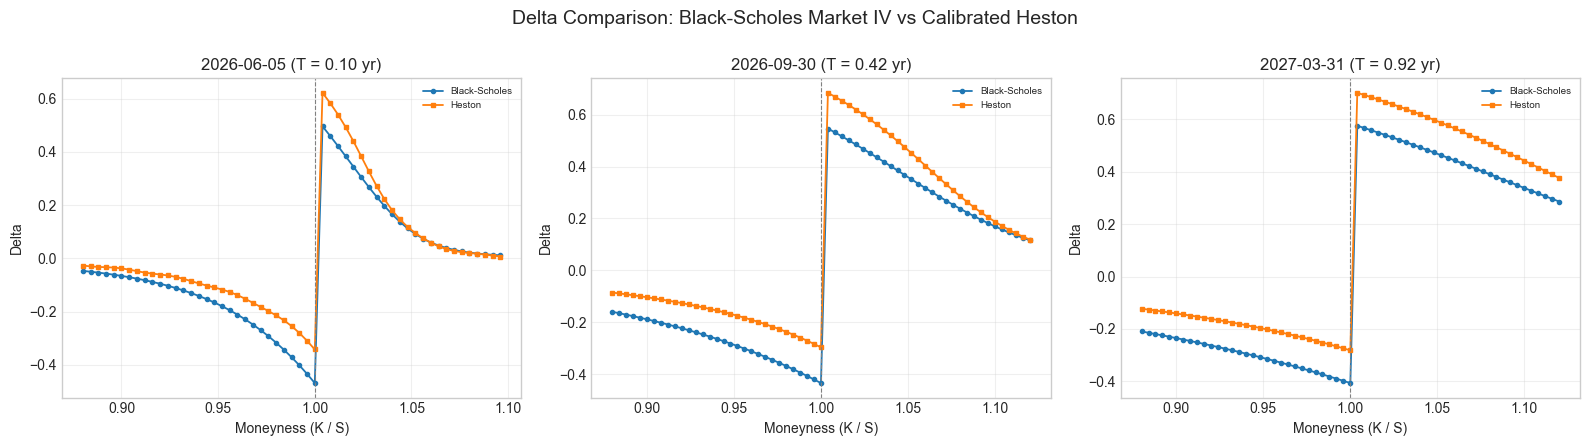

In [7]:
fig, axes = plot_greek_comparison(
    greeks_df=greeks_df,
    greek="delta",
    title="Delta Comparison: Black-Scholes Market IV vs Calibrated Heston",
    columns=3,
)
plt.show()

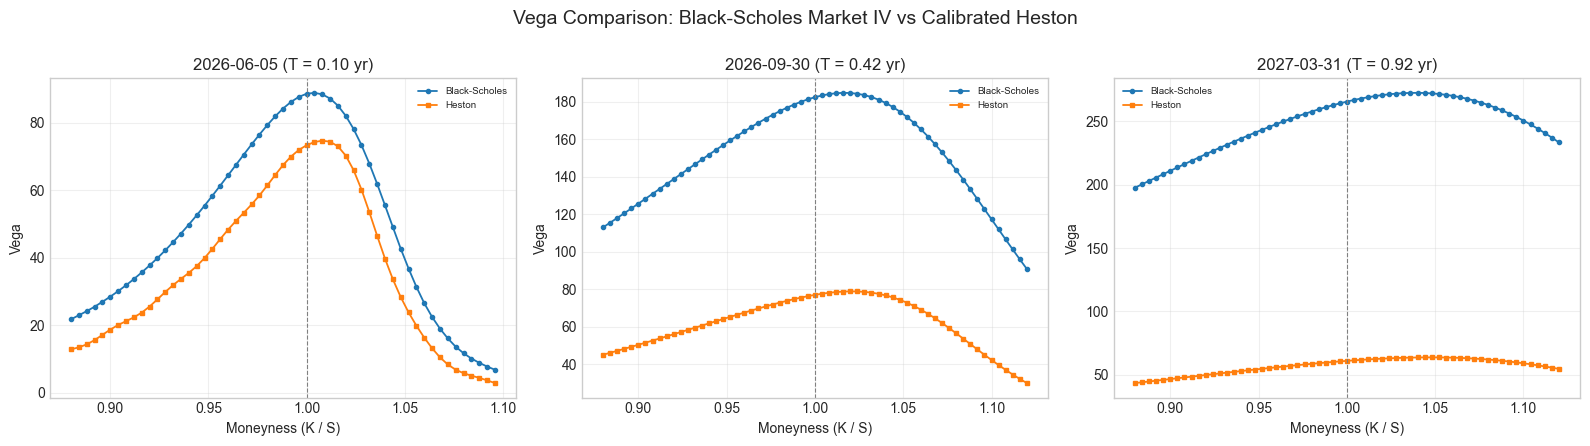

In [8]:
fig, axes = plot_greek_comparison(
    greeks_df=greeks_df,
    greek="vega",
    title="Vega Comparison: Black-Scholes Market IV vs Calibrated Heston",
    columns=3,
)
plt.show()

In [9]:
greek_summary = greeks_df.assign(
    delta_diff=greeks_df["heston_delta"] - greeks_df["bs_delta"],
    vega_diff=greeks_df["heston_vega"] - greeks_df["bs_vega"],
).groupby("expiry", observed=False).agg(
    count=("strike", "size"),
    mean_delta_diff=("delta_diff", "mean"),
    rmse_delta_diff=("delta_diff", lambda x: np.sqrt(np.mean(np.square(x)))),
    mean_vega_diff=("vega_diff", "mean"),
    rmse_vega_diff=("vega_diff", lambda x: np.sqrt(np.mean(np.square(x)))),
)

display(greek_summary.reset_index())

,expiry,count,mean_delta_diff,rmse_delta_diff,mean_vega_diff,rmse_vega_diff
0,2026-06-05,55,0.048065,0.064231,-12.420060,12.960608
1,2026-09-30,61,0.093106,0.101421,-90.052389,90.997787
2,2027-03-31,61,0.112030,0.112708,-191.406145,192.059944


## Final Conclusions

### 1. How well did Heston capture the volatility smile?

Black-Scholes with a single volatility cannot explain the SPY smile. For a given expiry it predicts a flat implied-volatility line, while the market shows a clear equity-index skew: lower strikes have higher implied volatility, higher strikes have lower implied volatility, and the slope changes with maturity. Black-Scholes can still match individual option prices by using a different market IV for every strike, but then the volatility surface is an external patch rather than an output of the model.

Heston improves this because volatility is stochastic and correlated with the underlying. The calibrated parameters are economically consistent with the SPY smile: `rho = -0.712` creates the negative spot-volatility relationship behind downside skew; `sigma_v = 1.067` gives enough volatility-of-volatility to create curvature; `kappa = 2.517` implies relatively fast mean reversion. The initial volatility is about 15.1%, the long-run volatility is about 25.7%, and the variance half-life is about 0.28 years, or roughly 3.3 months.

The fit is materially better than a flat-volatility Black-Scholes model. The final calibration used 1,061 filtered OTM options across 16 expiries. On that calibration set, the diagnostic price RMSE is about $0.31, the relative price RMSE is about 5.1%, and the true model-IV RMSE is about 1.29 volatility points. The Heston overlay follows the broad downward skew and term-structure pattern with one parameter set, while Black-Scholes needs a separate implied volatility for each strike and maturity.

The model is still not a perfect quote-by-quote fit. The all-valid-options smile includes ITM quotes and call-put discrepancies, while Heston produces one internally consistent model curve. A five-parameter diffusion cannot fully capture microstructure noise, short-term event risk, jump risk, or every maturity-specific distortion. The Feller ratio is about 0.29, so the strict Feller condition is not satisfied. This is common in equity-index Heston calibrations and does not invalidate characteristic-function pricing, but it means the calibrated variance process can approach zero.

### 2. Practical implications for risk management and hedging

**Delta hedging.** A trader using Black-Scholes delta with market IV at each strike and a trader using Heston delta may get similar hedge ratios near ATM, but the hedge ratios can diverge on the wings. Heston delta is generated from one calibrated stochastic-volatility model, so it reflects the fact that large downside moves are associated with higher volatility. For a book spread across many strikes, this gives a more internally consistent set of deltas than treating every strike as its own separate Black-Scholes world.

**Vega risk.** This is one of the most important differences. Black-Scholes Vega measures sensitivity to a flat volatility input. Heston Vega in this notebook is sensitivity to the current variance state, converted onto an initial-volatility scale. Because Heston variance mean-reverts, longer-dated options do not respond to current volatility shocks the same way they do under a flat-volatility Black-Scholes model. A risk manager who uses only Black-Scholes Vega can overstate or misallocate volatility exposure, especially for options books with many maturities and strikes.

**Stress testing and tail risk.** Black-Scholes assumes lognormal returns with constant volatility. That misses volatility clustering and tends to underrepresent the way equity markets behave in stress, when spot falls and volatility rises together. Heston introduces stochastic variance and negative spot-vol correlation, which produces heavier tails and a more realistic downside-volatility relationship. This matters for scenario analysis, Value-at-Risk, margin calculations, and stress tests of option portfolios.

**Smile consistency.** The practical weakness of Black-Scholes is that it needs a different sigma for each `(K, T)` pair to match the market. That works for quoting liquid vanilla options, but it is less reliable when interpolating, extrapolating, or pricing less liquid instruments. Heston generates the surface from one parameter set, so prices and Greeks across strikes and maturities are linked by the same dynamics. This consistency is useful for structured products, variance-sensitive trades, and books whose risk depends on the whole shape of the volatility surface.

**Hedging exotic derivatives.** For path-dependent options such as barriers, Asians, lookbacks, autocallables, or volatility-linked structures, the evolution of volatility through time matters, not just the terminal distribution. Black-Scholes assumes volatility is constant along the path. Heston models volatility as a stochastic process correlated with the underlying, so it gives a more realistic framework for hedging products whose value depends on both spot movement and volatility movement during the life of the trade.

The final takeaway is that Black-Scholes remains the clean benchmark and the standard implied-volatility language, but Heston is better suited for smile-aware pricing and risk management. It captures the main SPY skew with economically meaningful parameters, produces more coherent Greeks across the surface, and gives traders a better framework for hedging portfolios where volatility is neither flat nor constant.
